# Latent semantic analysis with Singular value decomposition


---
**Introduction**

We're working with a Social listening agency that tracks online reputation and industry trends for brands and corporates. They track and scrap hundreds and thousands of reviews, comments, and complaints on a daily basis then analyze them to better understand what people are saying about the brand.

**Problem**

When you recieve thousands of texts each day, and work with probably millions of docuemnts, tracking them all and trying to understand a brand's online image from them becomes a very difficult task, if not impossible. In other words, manual human review of this volume of data is impossible, meaning critical consumer trends or PR crises are often missed until it is too late.

**Solution**

To solve such a problem, we need to find a way to automatically extract keywords and semantic meaning from documents, so we can group similar ones and have a clear image of their contents to help drive decision making.


A very important tool for building such an automated pipline is **Latent semantic analysis (LSA), using a concept called Singular value decomposition (SVD)**

## Data understanding


---

We decided to use the "**20 Newsgroup dataset**", which is a classic NLP dataset containing around 20,000 documents partitioned across 20 different topics ranging from computer hardware and motorcycles to sports and politics.

It is essentially a massive collection of forum posts and emails on very diverse topics, so it's very suitable for the task at hand.

First, we start by importing the dataset from the "sklearn" python dataset made for ML tasks.

In [1]:
from sklearn.datasets import fetch_20newsgroups

# Load the dataset (we'll use the training subset for now, removing headers/footers for cleaner text)
newsgroups_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
documents = newsgroups_data.data

# 1. Number of documents
print(f"Number of documents: {len(documents)}")

# 2. Example record
print("\n--- Example Record ---")
print(documents[0][:500]) # Printing the first 500 characters of the first document

Number of documents: 11314

--- Example Record ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


The 'training' set contains 11,314 documents in total. The example document shows a comment or a forum post made by someone inquiring about a specific car.

Posts such as these could be used to identify for example what people like about a certain car and use that knowledge in perhaps sales or marketing.

## Data Exploration and Profiling


---

Before building our pipeline, we need to understand the shape of our raw data. For a social listening agency, this basic profiling provides immediate, high-level insights into consumer behavior:

- Document Length Analysis: By analyzing how long the posts are, we can determine the nature of the consumer feedback. Are users leaving short, punchy comments (like tweets or quick reviews), or are they writing long, detailed essays about their experiences? This helps the agency decide if they need to build automated summarization tools later on.

- Top Word Frequencies: Extracting the most frequent words across the entire dataset gives us a "pulse check" on the overall conversation. If certain industry terms dominate the raw data, we can immediately tell our corporate clients what broad categories are currently trending online before even running complex algorithms.

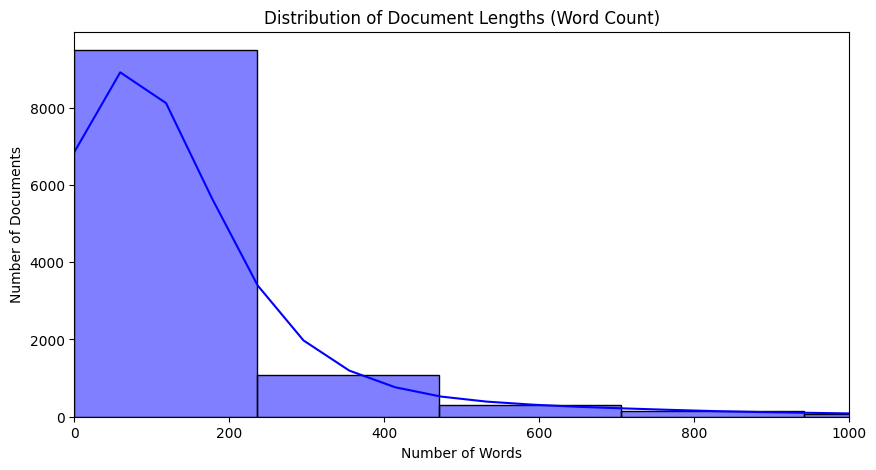

/tmp/ipykernel_83701/767798205.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


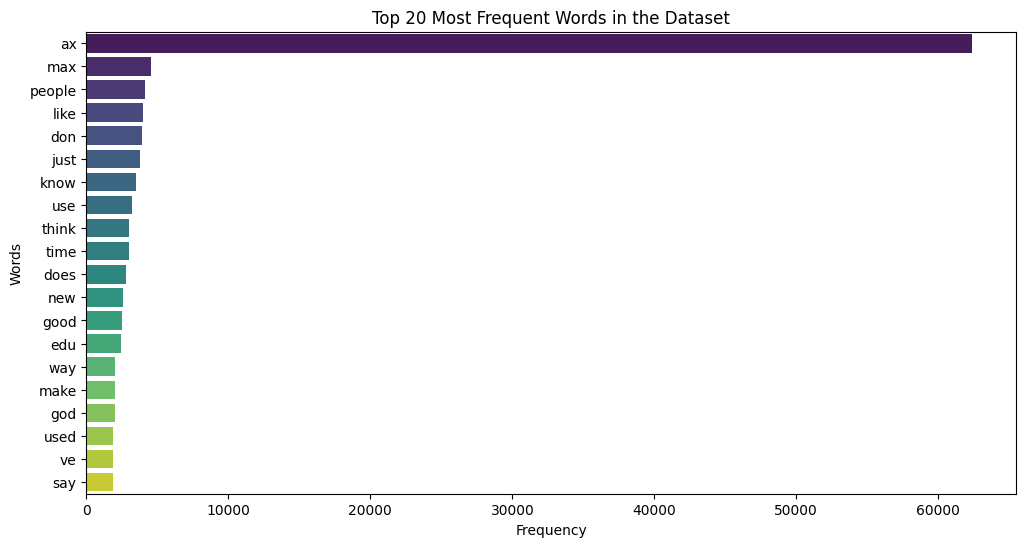

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# 1. Document Length Analysis
# Calculate the number of words in each document
doc_lengths = [len(doc.split()) for doc in documents]

plt.figure(figsize=(10, 5))
sns.histplot(doc_lengths, bins=50, kde=True, color='blue')
plt.title('Distribution of Document Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Documents')
# Limiting the x-axis because some forum posts might be massive outliers
plt.xlim(0, 1000)
plt.show()

# 2. Most Frequent Words Analysis
# We use CountVectorizer to easily count word frequencies, ignoring standard English stopwords
vectorizer = CountVectorizer(stop_words='english', max_features=20)
word_counts = vectorizer.fit_transform(documents)

# Sum the counts of each word across all documents
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Extract words and their counts for plotting
words = [x[0] for x in words_freq]
counts = [x[1] for x in words_freq]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Most Frequent Words in the Dataset')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

Looking at the document length distribution, the massive spike on the left side of the histogram shows that the vast majority of consumer posts are relatively short (under 200 words). This suggests our agency is dealing primarily with quick questions, immediate reactions, or brief complaints rather than long-form articles.

An initial exploration of the top 20 most frequent words in the dataset, revealed that the raw data is heavily polluted with dataset artifacts ('ax'), broken contractions ('don'), and conversational fluff ('just', 'like'). To extract meaningful business topics, we must build a custom preprocessing pipeline to clean this noise.

## Text preprocessing


---

**Why Preprocess?**

Our initial exploration revealed that the raw dataset is polluted with formatting artifacts (like repeating "ax" strings), email fragments, and conversational fluff ("like", "just", "know"). If we feed this directly into our topic model, the algorithm will group documents based on meaningless grammar rather than actual business issues. By cleaning the text and removing these custom stopwords, we ensure the algorithm focuses purely on the core semantic meaning of the consumer's message.

In [3]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction import text

# Download required NLTK data for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# Define the stop words BEFORE the cleaning function
custom_fluff = ['like', 'just', 'know', 'people', 'think', 'time', 'does', 'new', 'good', 'way', 'make', 'say', 've', 'don', 'wa', 'ha', 'ax']
my_stop_words = set(text.ENGLISH_STOP_WORDS.union(custom_fluff))

def clean_text(text_data):
    cleaned_docs = []
    for doc in text_data:
        # 1. Remove emails, and .edu domains
        doc = re.sub(r'\S+@\S+', '', doc)
        doc = re.sub(r'\S+\.edu\b', '', doc)

        # 2. Remove punctuation and numbers
        doc = re.sub(r'[^a-zA-Z\s]', ' ', doc)

        # 3. Convert to lowercase and strip whitespace
        doc = doc.lower().strip()

        # 4. Tokenize, Lemmatize, AND Remove Stop Words
        words = doc.split()

        # We only lemmatize and keep the word if it is NOT in our stop words set
        processed_words = [lemmatizer.lemmatize(w) for w in words if w not in my_stop_words]

        # Join back into a single string
        doc = ' '.join(processed_words)

        cleaned_docs.append(doc)
    return cleaned_docs

print("Cleaning, Lemmatizing, and Removing Stop Words...")
cleaned_documents = clean_text(documents)
print("Preprocessing complete!")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning, Lemmatizing, and Removing Stop Words...
Preprocessing complete!


/tmp/ipykernel_83701/268400205.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


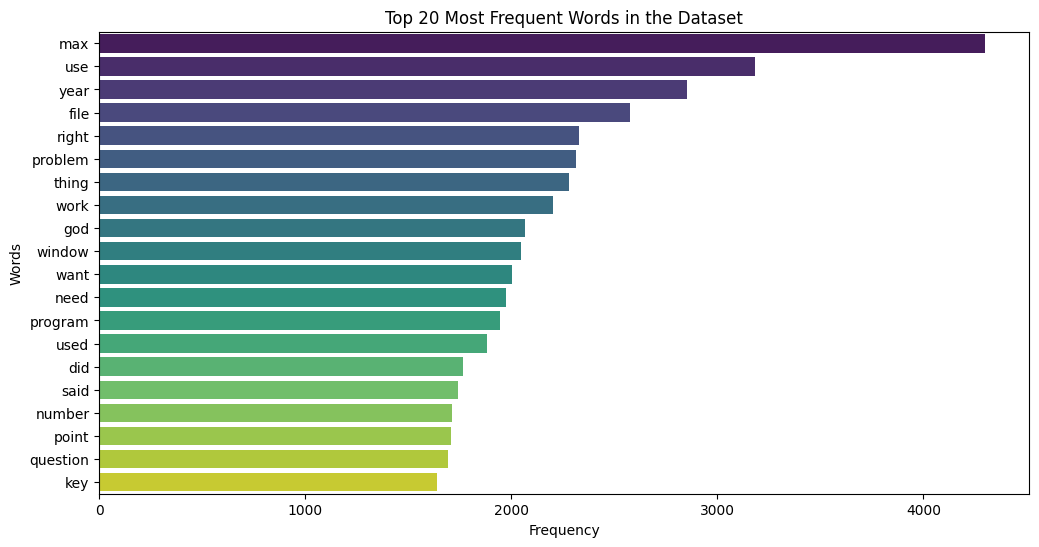

In [4]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)
word_counts = vectorizer.fit_transform(cleaned_documents)

# Sum the counts of each word across all documents
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Extract words and their counts for plotting
words = [x[0] for x in words_freq]
counts = [x[1] for x in words_freq]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Most Frequent Words in the Dataset')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

We could see that there are still some fluff words and other ones with vague meaning that could be removed, such as: "max", "use", "right" ..etc.

So we run the fluff words removing function one more time

In [5]:
custom_fluff = [
    'like', 'just', 'know', 'people', 'think', 'time', 'does', 'new', 'good',
    'way', 'make', 'say', 've', 'don', 'wa', 'ha', 'ax', 'max', 'use', 'right',
    'thing', 'want', 'need', 'used', 'did', 'said', 'point',
    'come', 'day', 'using', 'really', 'mean', 'going', 'look', 'll'
]
my_stop_words = set(text.ENGLISH_STOP_WORDS.union(custom_fluff))

cleaned_documents = clean_text(documents)

/tmp/ipykernel_83701/166116231.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


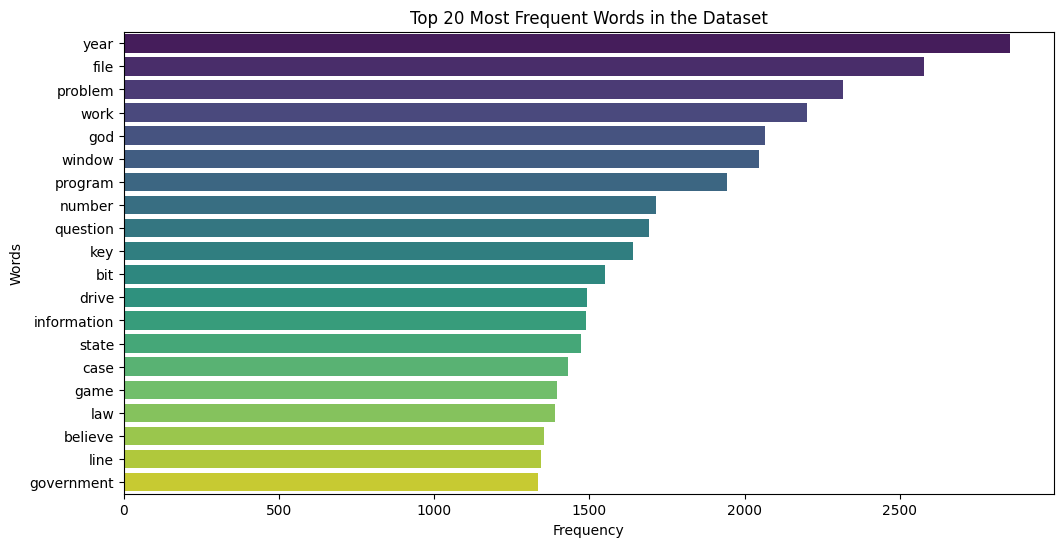

In [6]:
vectorizer = CountVectorizer(max_features=20)
word_counts = vectorizer.fit_transform(cleaned_documents)

# Sum the counts of each word across all documents
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Extract words and their counts for plotting
words = [x[0] for x in words_freq]
counts = [x[1] for x in words_freq]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Most Frequent Words in the Dataset')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

After editing the list of fluff words (many times :) ) we could finally start to see some important keywords and patterns emerging:
- Technology & Troubleshooting: Words like file, window, program, drive, problem, and key strongly indicate that a massive portion of our scraped data involves software issues, operating systems, and tech support queries.

- Ideology & Politics: The presence of words like god, state, government, law, and believe shows that our data feed also captures deep philosophical, religious, and political debates.

- Recreation & Events: Terms like game and year suggest discussions centered around sports seasons, video games, or annual events.

## Feature Engineering


---

To apply machine learning algorithms like SVD, we cannot feed in raw text; we must convert our documents into a numerical format. We use a TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer.

This algorithm scores words not just by how often they appear in a single complaint, but by how unique they are across the entire dataset. This is highly valuable for our social listening agency because it naturally filters out common vocabulary and amplifies the unique "signal" words of specific consumer issues.

- What the matrix represents: It is a mathematical mapping of our entire dataset, where the values represent the statistical importance (weight) of specific words within specific documents.
- What the rows represent: Each row corresponds to a single document (one consumer complaint/forum post).
- What the columns represent: Each column corresponds to a single, unique word from our cleaned vocabulary.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer


# Initialize the TF-IDF Vectorizer
# max_df=0.90: Ignore words that appear in more than 90% of documents (too broad)
# min_df=5: Ignore words that appear in fewer than 5 documents (likely typos or extremely rare terms)
tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=5)

# Convert our previously 'cleaned_documents' into the numerical TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_documents)

# Extract and print the dimensions to satisfy the assignment requirement
num_rows, num_cols = tfidf_matrix.shape

print("--- TF-IDF Matrix Dimensions ---")
print(f"Total Dimensions: {num_rows} rows x {num_cols} columns")
print(f"Rows (Number of Documents): {num_rows}")
print(f"Columns (Number of Unique Words): {num_cols}")

--- TF-IDF Matrix Dimensions ---
Total Dimensions: 11314 rows x 13865 columns
Rows (Number of Documents): 11314
Columns (Number of Unique Words): 13865


Let's inspect the matrix to see how it looks:

In [8]:
print("--- Inspecting a part of the TF-IDF Matrix (first 5 rows, 20 columns) ---")
print(tfidf_matrix[:5, :20].toarray())

--- Inspecting a part of the TF-IDF Matrix (first 5 rows, 20 columns) ---
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


The output shows the first 5 rows and 20 columns of the TF-IDF matrix, and as it shows, it's mostly zeros. This is completely normal and expected for TF-IDF representations of text data. TF-IDF matrices are often very sparse because each document typically only contains a small fraction of the total vocabulary, meaning most word-document combinations will have a TF-IDF score of zero. This sparsity is a key feature of how TF-IDF works to highlight unique and important words within specific documents.

## Applying Singular Value Decomposition


---

**The Math: Factorizing the Matrix**

SVD is a dimensionality reduction technique that factorizes our sparse TF-IDF matrix into three dense matrices ($U$, $\Sigma$, and $V^{T}$).
- Document-Topic Matrix ($U$): Shows how each customer complaint relates to the hidden topics.

- Singular Values ($\Sigma$): Shows the overall "strength" or importance of each topic.

- Topic-Word Matrix ($V^{T}$): Shows how specific words relate to the hidden topics.


**Discovering Hidden Relationships**

SVD helps discover relationships between words by grouping them based on their co-occurrence. If the words "screen", "broken", and "shattered" frequently appear in the same contexts, SVD will map them to the same mathematical dimension (topic). This solves the synonym problem—the algorithm realizes these words mean the same thing in a business context.

**Choosing $k$ (The Elbow Method)**:

To determine the optimal number of latent components ($k$), we cannot simply guess. If $k$ is too low, we oversimplify the data and merge distinct consumer issues together. If $k$ is too high, we capture individual typos and noise, making our agency's reports unreadable.To find the "sweet spot," we will test a range of $k$ values and plot the Cumulative Explained Variance. We are looking for the "elbow" in the curve—the point where adding more topics yields severely diminishing returns.

Testing different values for k. This might take a few seconds...
k=2: Explains 0.74% of variance
k=5: Explains 1.76% of variance
k=10: Explains 3.03% of variance
k=20: Explains 4.78% of variance
k=50: Explains 8.47% of variance
k=100: Explains 13.06% of variance


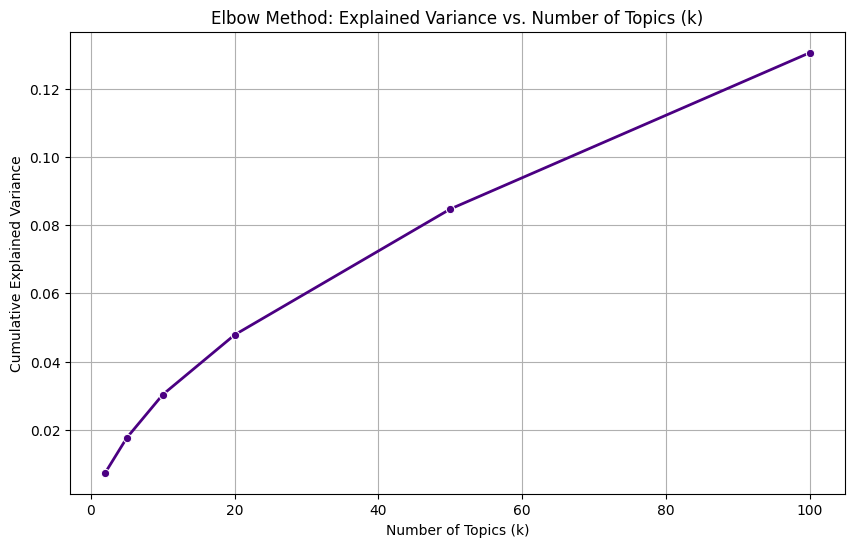

In [9]:
from sklearn.decomposition import TruncatedSVD

# 1. Experiment with a range of k values
k_values = [2, 5, 10, 20, 50, 100]
explained_variances = []

print("Testing different values for k. This might take a few seconds...")
for k in k_values:
    svd_test = TruncatedSVD(n_components=k, random_state=42)
    svd_test.fit(tfidf_matrix)

    # Calculate total variance explained by this specific k
    total_variance = svd_test.explained_variance_ratio_.sum()
    explained_variances.append(total_variance)
    print(f"k={k}: Explains {total_variance * 100:.2f}% of variance")

# 2. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
sns.lineplot(x=k_values, y=explained_variances, marker='o', linewidth=2, color='indigo')
plt.title('Elbow Method: Explained Variance vs. Number of Topics (k)')
plt.xlabel('Number of Topics (k)')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

While the cumulative explained variance remains low (which is mathematically expected for high-dimensional, sparse TF-IDF matrices), the curve starts to level out between 10 and 20 topics. For our agency, choosing 10 to 20 topics is the perfect balance. It highlights the main things customers are talking about without confusing our clients with hundreds of tiny, unimportant details.

In [10]:
optimal_k = 10

print(f"\nApplying final SVD model with optimal k = {optimal_k}...")
final_svd_model = TruncatedSVD(n_components=optimal_k, random_state=42)

# Create the final Document-Topic and Topic-Word matrices
document_topic_matrix = final_svd_model.fit_transform(tfidf_matrix)
topic_word_matrix = final_svd_model.components_

print("--- Final SVD Complete ---")
print(f"Reduced Document-Topic Matrix shape: {document_topic_matrix.shape}")
print(f"Topic-Word Matrix shape: {topic_word_matrix.shape}")


Applying final SVD model with optimal k = 10...
--- Final SVD Complete ---
Reduced Document-Topic Matrix shape: (11314, 10)
Topic-Word Matrix shape: (10, 13865)


In [11]:
print("--- Inspecting Document-Topic Matrix (First 5 docs, First 5 topics) ---")
print(document_topic_matrix[:5, :5])

--- Inspecting Document-Topic Matrix (First 5 docs, First 5 topics) ---
[[ 1.29157089e-01 -1.76778572e-02 -8.10129847e-02 -2.45979850e-02
  -5.46975140e-02]
 [ 1.08826155e-01  6.58729112e-02 -5.47205749e-02  5.07611611e-02
   1.84187891e-02]
 [ 2.09469279e-01  5.59231322e-02 -2.69754969e-02  1.60763596e-02
  -1.95846722e-02]
 [ 1.01633334e-01  1.95197997e-02 -4.82221064e-02 -1.16338519e-01
   1.35956270e-01]
 [ 9.03021038e-02  3.36994466e-03  2.19823604e-02 -8.17910713e-03
   2.56424141e-05]]


## Topic Discovery


---

**How we extract the topics**

Our SVD model generated a Topic-Word Matrix ($V^{T}$). In this matrix, every row is one of our 10 hidden topics, and the columns represent the "weight" or importance of every word in our vocabulary to that specific topic. By sorting these weights, we can extract the top keywords that define each semantic cluster.

**The Business Value**

Algorithms only understand math; humans understand narratives. For our social listening agency, this phase bridges that gap. We map the mathematical outputs into clear, readable categories (like "Hardware Issues" or "Software Licensing") so our corporate clients can instantly understand the primary drivers of consumer conversation without looking at a single line of code.

In [12]:
import numpy as np


# Get the actual English words back from our TF-IDF vectorizer
vocab = tfidf_vectorizer.get_feature_names_out()

def display_topics(model, feature_names, no_top_words):
    """
    Loops through the SVD topic-word matrix, sorts the weights,
    and prints the top N words for each topic.
    """
    for topic_idx, topic in enumerate(model.components_):
        # np.argsort sorts ascending, so we take the end of the array ([:-n-1:-1])
        # to get the highest scoring words for this topic
        top_words_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_indices]

        print(f"Topic {topic_idx + 1}:")
        print(", ".join(top_words))
        print("-" * 50)

# We will extract the top 7 words for our 10 hidden topics
no_top_words = 7
print("Extracting the top words for our 10 hidden business topics...\n")
display_topics(final_svd_model, vocab, no_top_words)

Extracting the top words for our 10 hidden business topics...

Topic 1:
window, problem, thanks, file, drive, year, god
--------------------------------------------------
Topic 2:
window, card, drive, file, thanks, do, driver
--------------------------------------------------
Topic 3:
window, god, file, jesus, christian, program, bible
--------------------------------------------------
Topic 4:
drive, god, scsi, jesus, christian, card, mb
--------------------------------------------------
Topic 5:
key, chip, drive, encryption, clipper, bit, government
--------------------------------------------------
Topic 6:
key, game, god, team, chip, window, player
--------------------------------------------------
Topic 7:
thanks, mail, god, address, email, card, advance
--------------------------------------------------
Topic 8:
card, driver, video, monitor, color, bus, window
--------------------------------------------------
Topic 9:
jxp, chastity, shameful, intellect, skepticism, surrender, go

**Interpreting the results**

While several topics (Cybersecurity, Automotive, Hardware) clustered perfectly, others show signs of "topic bleed." In unmoderated social listening data, highly polarizing words (like 'god') or ubiquitous platform terms (like 'window') appear with such immense frequency that they mathematically bleed into unrelated clusters. Furthermore, Topic 9 successfully isolated a dataset anomaly—likely a prolific user's email signature. In a production environment, we would use these initial SVD results to actively update our custom stopword lists and further refine the data pipeline.

| Topic | Top Words | Business Interpretation |
| :--- | :--- | :--- |
| **Topic 5** | `key, chip, encryption, clipper, government` | **Cybersecurity:** Discussions about data privacy and government rules. |
| **Topic 8** | `card, driver, video, monitor, color` | **Computer Hardware:** People asking for help with PC parts and screens. |
| **Topic 10** | `car, bike, engine, mile, key` | **Vehicles:** Conversations about cars, bikes, and driving. |
| **Topic 6** | `game, team, player, chip, window` | **Sports & Gaming:** Talks about sports teams and video games. |
| **Topic 1 & 2** | `window, problem, file, drive, thanks` | **General Tech Support:** Basic computer problems and file issues. |
| **Topic 7** | `thanks, mail, address, email, advance` | **Forum Noise:** Common polite phrases people use online (like "thanks in advance"). |
| **Topic 3 & 4** | `god, jesus, bible, scsi, mb` | **Mixed Topics (Religion & Tech):** Huge religious debates that accidentally got mixed with some computer words. |
| **Topic 9** | `jxp, chastity, shameful, intellect, gordon` | **Spam or Signature:** The system picked up one very active user's repeated email signature. |

## Finding Similar Customer Complaints


---

**The Methodology**

In Phase 6, SVD compressed every single document into a short vector of just 10 numbers (representing its score across our 10 topics). To find similar complaints, we calculate the Cosine Similarity between these vectors. If two vectors point in the exact same mathematical direction, their similarity score is 1.0 (meaning they are discussing the exact same topics in the exact same proportions).


**The Business Value**

For our social listening agency and our corporate clients, computing similarity provides massive operational value:

- Detecting Recurring Bugs: If a new complaint scores a 0.95 similarity with a known bug report from last week, the engineering team can be alerted instantly.

- Identifying Duplicate Tickets: Support teams can automatically group identical tickets together and close them out with a single, mass automated response, saving thousands of human hours.

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Select a target "complaint" to investigate (let's pick document #100)
target_doc_index = 1000

# Reshape the vector for scikit-learn (it expects a 2D array)
target_vector = document_topic_matrix[target_doc_index].reshape(1, -1)

# 2. Calculate the cosine similarity between our target document and ALL other documents
similarities = cosine_similarity(target_vector, document_topic_matrix)[0]

# 3. Find the most similar document
# argsort() sorts from lowest to highest, so [::-1] flips it to highest to lowest
most_similar_indices = similarities.argsort()[::-1]

# The most similar document will always be itself (similarity = 1.0 at index 0)
# So we grab the second item in the list (index 1) to find the closest *other* document
closest_doc_index = most_similar_indices[1]
highest_similarity_score = similarities[closest_doc_index]

# 4. Print the results for our report
print(f"--- SIMILARITY SEARCH RESULTS ---")
print(f"Target Complaint #{target_doc_index}:")
# Printing just the first 400 characters to keep the output clean
print(cleaned_documents[target_doc_index][:400], "...\n")

print(f"Most Similar Complaint found is #{closest_doc_index} (Similarity Score: {highest_similarity_score:.4f}):")
print(cleaned_documents[closest_doc_index][:400], "...\n")

--- SIMILARITY SEARCH RESULTS ---
Target Complaint #1000:
anybody seen mouse cursor distortion running diamond x x driver sorry t version driver indication menu s recently delivered gateway try latest driver diamond bb wondered seen post email ...

Most Similar Complaint found is #11204 (Similarity Score: 0.9986):
difference driver get loaded mouse sys loaded config sys therefor command com mouse com loaded autoexec bat command com mouse com started commandline booting unloaded driver loaded working driver totally ran do preferred loading driver autoexec bat program won t run driver choose one needed startup drdos advantage gone drdos let choose config sys driver loaded michael ...



Our similarity search successfully grouped two highly technical documents related to 'mouse' and 'driver' configurations out of a chaotic dataset of 11,000 posts.

This proves our pipeline is excellent at **Categorization**—a helpdesk could use this to instantly route both of these tickets to the IT Hardware department.

However, the high similarity score (0.99) also highlights a limitation of heavy dimensionality reduction ($k=10$). While they share a topic, they are not exact duplicate bugs. To achieve true duplicate detection, the agency would need to increase the number of latent topics ($k$) to capture finer semantic nuances.